In [25]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/titanic/train.csv
/kaggle/input/competitions/titanic/test.csv
/kaggle/input/competitions/titanic/gender_submission.csv


# Dagshub/Mlflow initialization

In [26]:
pip install dagshub mlflow scikit-learn pandas matplotlib seaborn skops --quiet

Note: you may need to restart the kernel to use updated packages.


In [27]:
import dagshub
import mlflow
import mlflow.sklearn

#dagshub.init(repo_owner='YOUR_DAGSHUB_USERNAME', repo_name='YOUR_REPO_NAME', mlflow=True)
dagshub.init(repo_owner='tvani2', repo_name='titanic_tutoring', mlflow=True)

Initialized MLflow to track repo "tvani2/titanic_tutoring"

Repository tvani2/titanic_tutoring initialized!

In [28]:
#print(mlflow.get_tracking_uri())

# Exploratory Data Analysis (EDA)

In [29]:
df = pd.read_csv("/kaggle/input/competitions/titanic/train.csv")

In [30]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["Survived"])
y = df["Survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size: {X_train.shape}")
print(f"Test size:  {X_test.shape}")

Train size: (712, 11)
Test size:  (179, 11)


In [31]:
print(X_train.describe())

       PassengerId      Pclass         Age       SibSp       Parch        Fare
count   712.000000  712.000000  575.000000  712.000000  712.000000  712.000000
mean    444.405899    2.308989   29.807687    0.492978    0.390449   31.819826
std     257.465527    0.833563   14.485211    1.060720    0.838134   48.059104
min       1.000000    1.000000    0.420000    0.000000    0.000000    0.000000
25%     222.750000    2.000000   21.000000    0.000000    0.000000    7.895800
50%     439.500000    3.000000   28.500000    0.000000    0.000000   14.454200
75%     667.250000    3.000000   39.000000    1.000000    0.000000   31.000000
max     891.000000    3.000000   80.000000    8.000000    6.000000  512.329200


In [32]:
print(X_train.isnull().sum())

PassengerId      0
Pclass           0
Name             0
Sex              0
Age            137
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          552
Embarked         2
dtype: int64


In [33]:
print(X_train.info())

<class 'pandas.core.frame.DataFrame'>
Index: 712 entries, 692 to 507
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  712 non-null    int64  
 1   Pclass       712 non-null    int64  
 2   Name         712 non-null    object 
 3   Sex          712 non-null    object 
 4   Age          575 non-null    float64
 5   SibSp        712 non-null    int64  
 6   Parch        712 non-null    int64  
 7   Ticket       712 non-null    object 
 8   Fare         712 non-null    float64
 9   Cabin        160 non-null    object 
 10  Embarked     710 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 66.8+ KB
None


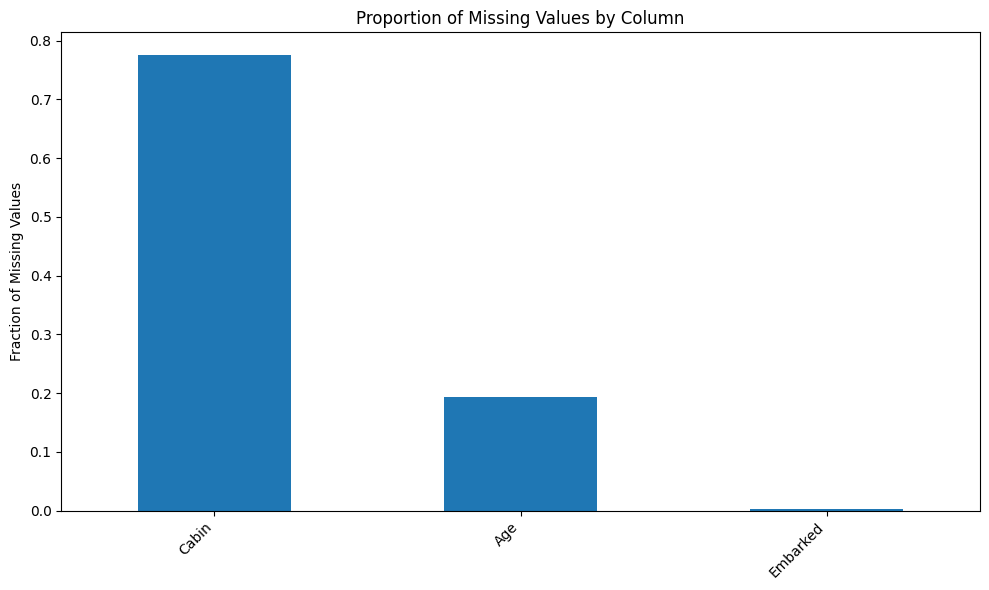

In [34]:
import matplotlib.pyplot as plt

null_ratio = X_train.isna().sum() / X_train.shape[0]
null_ratio = null_ratio[null_ratio > 0].sort_values(ascending=False)

plt.figure(figsize=(10, 6))
null_ratio.plot(kind='bar')
plt.title('Proportion of Missing Values by Column')
plt.ylabel('Fraction of Missing Values')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [35]:
cat_cols = [col for col in X_train.columns if X_train[col].dtype == 'object']
num_cols = [col for col in X_train.columns if X_train[col].dtype != 'object']

print(f"Categorical columns ({len(cat_cols)}): {cat_cols}")
print(f"Numerical columns ({len(num_cols)}): {num_cols}")

Categorical columns (5): ['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked']
Numerical columns (6): ['PassengerId', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']


<Figure size 1500x1000 with 0 Axes>

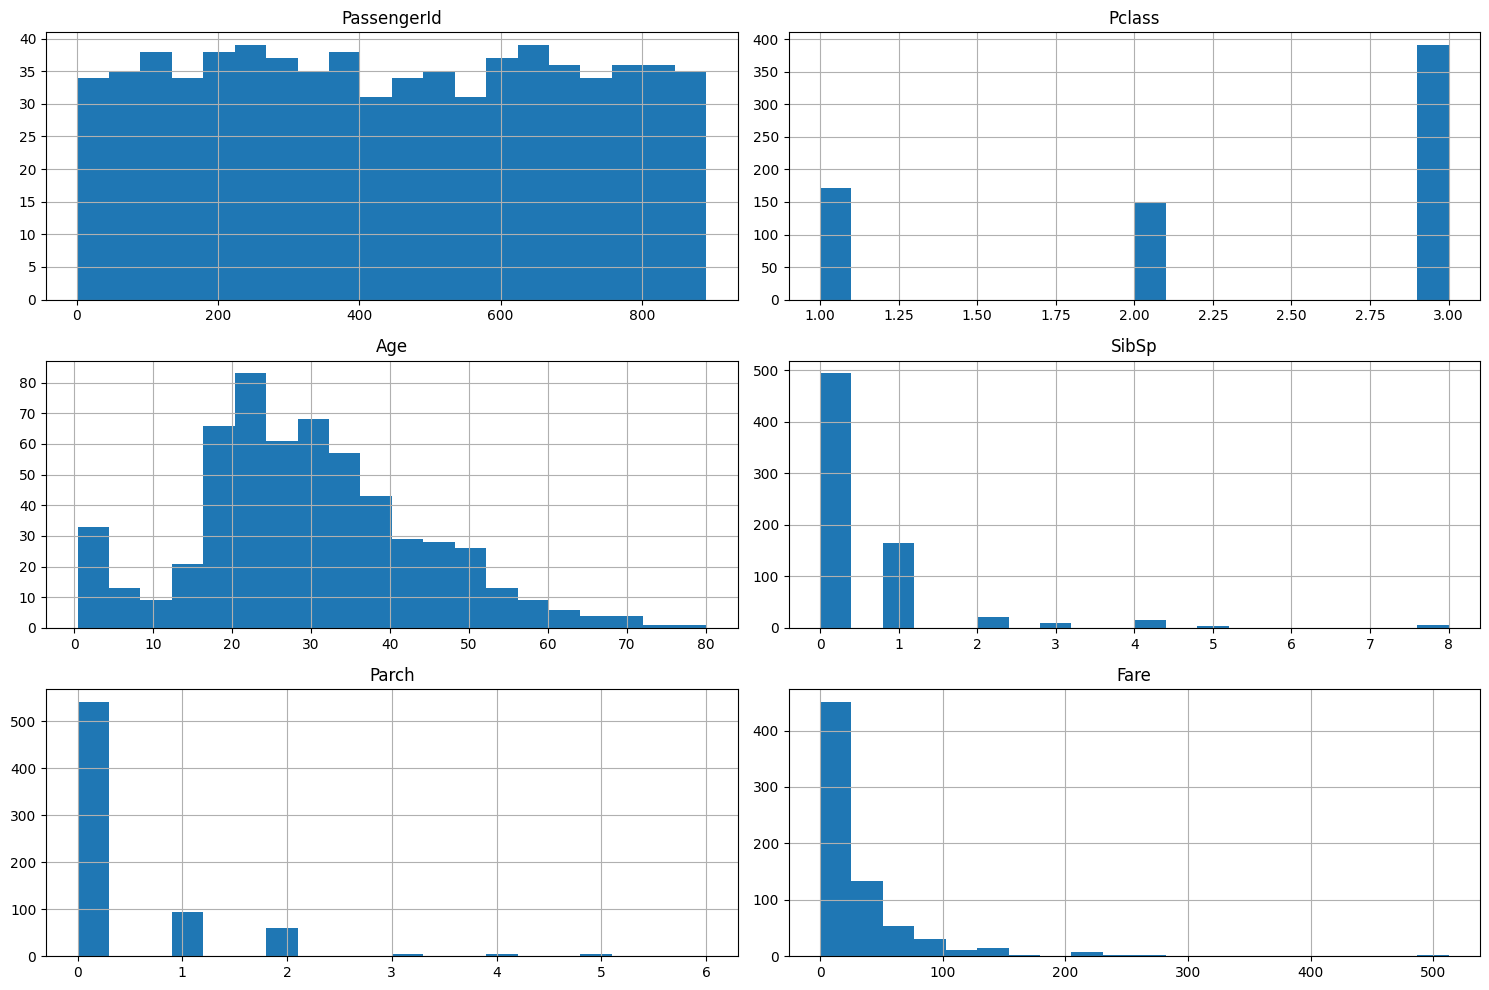

In [36]:
import matplotlib.pyplot as plt

X_train[num_cols].describe()

plt.figure(figsize=(15, 10))
X_train[num_cols].hist(bins=20, figsize=(15, 10))
plt.tight_layout()
plt.show()

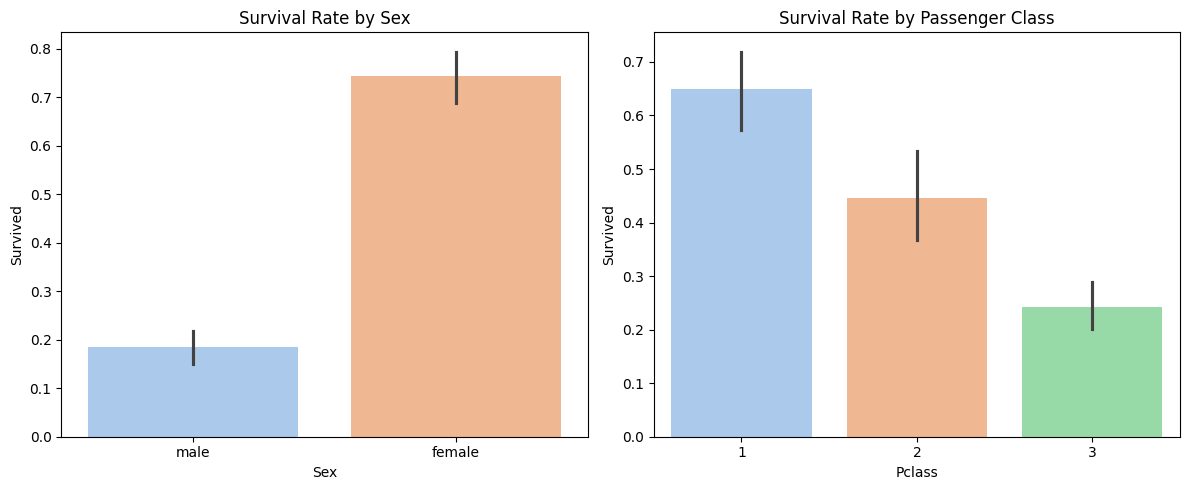

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

train_plot = X_train.copy()
train_plot["Survived"] = y_train.values

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.barplot(x='Sex', y='Survived', data=train_plot, ax=axes[0], palette='pastel', hue='Sex', legend=False)
axes[0].set_title('Survival Rate by Sex')
sns.barplot(x='Pclass', y='Survived', data=train_plot, ax=axes[1], palette='pastel', hue='Pclass', legend=False)
axes[1].set_title('Survival Rate by Passenger Class')
plt.tight_layout()
plt.show()

# Data Cleaning

In [42]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer


high_nan_cols  = ["Cabin"]
num_to_impute  = ["Age", "Fare"]
ohe_cols       = ["Sex", "Embarked"]
useless_cols   = ["Name", "Ticket", "PassengerId"] 
woe_cols       = ["remainder__Pclass"]

ohe_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("ohe",    OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("drop_high_nan", "drop",                               high_nan_cols),
        ("drop_useless",  "drop",                               useless_cols),
        ("num_impute",    SimpleImputer(strategy="median"),     num_to_impute),
        ("ohe",           ohe_pipeline,                        ohe_cols),
    ],
    remainder="passthrough"  
)

# Feature Engineering

In [43]:
from sklearn.base import BaseEstimator, TransformerMixin

class FamilySizeAdder(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        X = X.copy()
        X["FamilySize"] = X["SibSp"] + X["Parch"] + 1
        return X

In [44]:
class ColumnNameRestorer(BaseEstimator, TransformerMixin):
    def __init__(self, column_transformer):
        self.column_transformer = column_transformer

    def fit(self, X, y=None):
        self.feature_names_ = self.column_transformer.get_feature_names_out()
        return self

    def transform(self, X):
        return pd.DataFrame(X, columns=self.feature_names_)

In [45]:
import numpy as np

class WOEEncoder(BaseEstimator, TransformerMixin):
    def __init__(self, cols):
        self.cols = cols
        self.woe_map = {}

    def fit(self, X, y):
        X = X.copy()
        for col in self.cols:
            stats = pd.DataFrame({"col": X[col], "target": y})
            total_events = y.sum()           # total survived
            total_non_events = (1 - y).sum() # total not survived

            woe_dict = {}
            for val, group in stats.groupby("col"):
                events = group["target"].sum()
                non_events = (1 - group["target"]).sum()

                # avoid division by zero
                dist_events = (events + 0.5) / (total_events + 0.5)
                dist_non_events = (non_events + 0.5) / (total_non_events + 0.5)

                woe_dict[val] = np.log(dist_events / dist_non_events)
            self.woe_map[col] = woe_dict
        return self

    def transform(self, X):
        X = X.copy()
        for col in self.cols:
            X[col] = X[col].map(self.woe_map[col]).fillna(0)
        return X

# Feature Selection

In [46]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression

class RFESelector(BaseEstimator, TransformerMixin):
    def __init__(self, n_features_to_select=8):
        self.n_features_to_select = n_features_to_select
        self.selected_features_ = None
        self.rfe_ = None

    def fit(self, X, y):
        X = pd.DataFrame(X).reset_index(drop=True)
        self.feature_names_ = list(X.columns)
        
        estimator = LogisticRegression(max_iter=1000, random_state=42)
        self.rfe_ = RFE(estimator=estimator, n_features_to_select=self.n_features_to_select)
        self.rfe_.fit(X, y)
        
        self.selected_features_ = [
            f for f, s in zip(self.feature_names_, self.rfe_.support_) if s
        ]
        print(f"RFE selected features: {self.selected_features_}")
        return self

    def transform(self, X):
        X = pd.DataFrame(X).reset_index(drop=True)
        X.columns = self.feature_names_
        return X[self.selected_features_]

In [47]:
class CorrelationFilter(BaseEstimator, TransformerMixin):
    def __init__(self, threshold=0.85):
        self.threshold = threshold
        self.features_to_drop_ = None
        self.selected_features_ = None

    def fit(self, X, y=None):
        X = pd.DataFrame(X).reset_index(drop=True)
        
        corr_matrix = X.corr().abs()
        
        # upper triangle only to avoid duplicates
        upper = corr_matrix.where(
            np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
        )

        # drop the column with higher mean correlation when a pair exceeds threshold
        self.features_to_drop_ = set()
        for col in upper.columns:
            if any(upper[col] > self.threshold):
                partners = upper.index[upper[col] > self.threshold].tolist()
                for partner in partners:
                    # drop whichever of the pair has higher mean correlation
                    if corr_matrix[col].mean() >= corr_matrix[partner].mean():
                        self.features_to_drop_.add(col)
                    else:
                        self.features_to_drop_.add(partner)

        self.selected_features_ = [
            col for col in X.columns if col not in self.features_to_drop_
        ]

        print(f"Correlation filter dropped: {self.features_to_drop_}")
        print(f"Correlation filter kept:    {self.selected_features_}")
        return self

    def transform(self, X):
        X = pd.DataFrame(X).reset_index(drop=True)
        return X[self.selected_features_]

In [48]:
class IVValidator(BaseEstimator, TransformerMixin):
    def __init__(self, threshold=0.02):
        # IV interpretation:
        # < 0.02  → useless
        # 0.02–0.1 → weak
        # 0.1–0.3 → medium
        # 0.3+    → strong
        self.threshold = threshold
        self.iv_scores_ = {}
        self.selected_features_ = None

    def _compute_iv(self, X, y, col):
        df = pd.DataFrame({"col": X[col], "target": y})
        total_events = y.sum()
        total_non_events = (1 - y).sum()

        iv = 0
        for val, group in df.groupby("col"):
            events = group["target"].sum()
            non_events = (1 - group["target"]).sum()

            dist_e  = (events + 0.5) / (total_events + 0.5)
            dist_ne = (non_events + 0.5) / (total_non_events + 0.5)

            woe = np.log(dist_e / dist_ne)
            iv += (dist_e - dist_ne) * woe
        return iv

    def fit(self, X, y):
        X = pd.DataFrame(X).reset_index(drop=True)
        y = pd.Series(y).reset_index(drop=True)

        self.iv_scores_ = {}
        for col in X.columns:
            self.iv_scores_[col] = self._compute_iv(X, y, col)

        print("\nIV Scores:")
        for col, iv in sorted(self.iv_scores_.items(), key=lambda x: -x[1]):
            label = (
                "useless" if iv < 0.02 else
                "weak"    if iv < 0.1  else
                "medium"  if iv < 0.3  else
                "strong"
            )
            print(f"  {col}: {iv:.4f} ({label})")

        self.selected_features_ = [
            col for col, iv in self.iv_scores_.items() if iv >= self.threshold
        ]
        print(f"\nIV kept features: {self.selected_features_}")
        return self

    def transform(self, X):
        X = pd.DataFrame(X).reset_index(drop=True)
        return X[self.selected_features_]

# Full Pipeline

In [49]:
preprocessing_pipeline = Pipeline([
    ("family_size", FamilySizeAdder()),
    ("preprocessor", preprocessor),
    ("col_restorer", ColumnNameRestorer(preprocessor)),
    ("woe", WOEEncoder(cols=woe_cols)),
    ("rfe", RFESelector(n_features_to_select=8)),
    ("corr_filter", CorrelationFilter(threshold=0.85)),
    ("iv", IVValidator(threshold=0.02)),
])

In [50]:
import skops.io as sio

with mlflow.start_run(run_name="preprocessing_pipeline"):
    mlflow.log_param("high_nan_cols",       str(high_nan_cols))
    mlflow.log_param("num_impute_strategy", "median")
    mlflow.log_param("cat_impute_strategy", "most_frequent")
    mlflow.log_param("woe_cols",            str(woe_cols))
    mlflow.log_param("ohe_cols",            str(ohe_cols))
    mlflow.log_param("rfe_n_features",      8)
    mlflow.log_param("corr_threshold",      0.85)
    mlflow.log_param("iv_threshold",        0.02)

    preprocessing_pipeline.fit(X_train, y_train)

    # save with skops and log as artifact (not log_model)
    sio.dump(preprocessing_pipeline, "preprocessing_pipeline.skops")
    mlflow.log_artifact("preprocessing_pipeline.skops")

    preprocessing_run_id = mlflow.active_run().info.run_id
    print(f"Preprocessing run id: {preprocessing_run_id}")

# transform
X_train_transformed = preprocessing_pipeline.transform(X_train)
X_test_transformed  = preprocessing_pipeline.transform(X_test)

RFE selected features: ['ohe__Sex_female', 'ohe__Sex_male', 'ohe__Embarked_C', 'ohe__Embarked_S', 'remainder__Pclass', 'remainder__SibSp', 'remainder__Parch', 'remainder__FamilySize']
Correlation filter dropped: {'remainder__FamilySize', 'ohe__Sex_male'}
Correlation filter kept:    ['ohe__Sex_female', 'ohe__Embarked_C', 'ohe__Embarked_S', 'remainder__Pclass', 'remainder__SibSp', 'remainder__Parch']

IV Scores:
  ohe__Sex_female: 1.3682 (strong)
  remainder__Pclass: 0.5224 (strong)
  remainder__SibSp: 0.1866 (medium)
  remainder__Parch: 0.1429 (medium)
  ohe__Embarked_C: 0.1329 (medium)
  ohe__Embarked_S: 0.1327 (medium)

IV kept features: ['ohe__Sex_female', 'ohe__Embarked_C', 'ohe__Embarked_S', 'remainder__Pclass', 'remainder__SibSp', 'remainder__Parch']
Preprocessing run id: 48928553183941d8975d256fbbf20d86
🏃 View run preprocessing_pipeline at: https://dagshub.com/tvani2/titanic_tutoring.mlflow/#/experiments/0/runs/48928553183941d8975d256fbbf20d86
🧪 View experiment at: https://dagshu

# Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import KFold, cross_validate
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, precision_score, recall_score

kf = KFold(n_splits=5, shuffle=True, random_state=42)

# different parameter combinations to test
param_grid = [
    # L2 with lbfgs (default, reliable)
    {"C": 0.01,  "solver": "lbfgs",     "penalty": "l2"},
    {"C": 0.1,   "solver": "lbfgs",     "penalty": "l2"},
    {"C": 1.0,   "solver": "lbfgs",     "penalty": "l2"},
    {"C": 10.0,  "solver": "lbfgs",     "penalty": "l2"},

    # L1 with liblinear (feature selection effect)
    {"C": 0.01,  "solver": "liblinear", "penalty": "l1"},
    {"C": 0.1,   "solver": "liblinear", "penalty": "l1"},
    {"C": 1.0,   "solver": "liblinear", "penalty": "l1"},
    {"C": 10.0,  "solver": "liblinear", "penalty": "l1"},

    # L1 with saga
    {"C": 0.1,   "solver": "saga",      "penalty": "l1"},
    {"C": 1.0,   "solver": "saga",      "penalty": "l1"},

    # L2 with saga
    {"C": 0.1,   "solver": "saga",      "penalty": "l2"},
    {"C": 1.0,   "solver": "saga",      "penalty": "l2"},
]

mlflow.set_experiment("logistic_regression")

for params in param_grid:
    with mlflow.start_run(run_name=f"LR_C{params['C']}_{params['solver']}"):

        # tag the preprocessing run so you know which pipeline was used
        mlflow.set_tag("preprocessing_run_id", preprocessing_run_id)
        mlflow.set_tag("model_type", "LogisticRegression")

        model = LogisticRegression(**params, random_state=42)

        # — cross validation on X_train_transformed —
        cv_results = cross_validate(
            model, X_train_transformed, y_train,
            cv=kf,
            scoring=["accuracy", "f1", "roc_auc", "precision", "recall"],
            return_train_score=True
        )

        # log params
        mlflow.log_params(params)

        # log average train scores
        mlflow.log_metric("train_accuracy",  cv_results["train_accuracy"].mean())
        mlflow.log_metric("train_f1",        cv_results["train_f1"].mean())
        mlflow.log_metric("train_roc_auc",   cv_results["train_roc_auc"].mean())
        mlflow.log_metric("train_precision", cv_results["train_precision"].mean())
        mlflow.log_metric("train_recall",    cv_results["train_recall"].mean())

        # log average validation scores
        mlflow.log_metric("val_accuracy",    cv_results["test_accuracy"].mean())
        mlflow.log_metric("val_f1",          cv_results["test_f1"].mean())
        mlflow.log_metric("val_roc_auc",     cv_results["test_roc_auc"].mean())
        mlflow.log_metric("val_precision",   cv_results["test_precision"].mean())
        mlflow.log_metric("val_recall",      cv_results["test_recall"].mean())

        # — final test scores — fit on full X_train_transformed first —
        model.fit(X_train_transformed, y_train)
        test_preds = model.predict(X_test_transformed)
        test_proba = model.predict_proba(X_test_transformed)[:, 1]

        mlflow.log_metric("test_accuracy",   accuracy_score(y_test, test_preds))
        mlflow.log_metric("test_f1",         f1_score(y_test, test_preds))
        mlflow.log_metric("test_roc_auc",    roc_auc_score(y_test, test_proba))
        mlflow.log_metric("test_precision",  precision_score(y_test, test_preds))
        mlflow.log_metric("test_recall",     recall_score(y_test, test_preds))

        # log model
        sio.dump(model, "model.skops")
        mlflow.log_artifact("model.skops")

        print(f"C={params['C']} solver={params['solver']} | "
              f"val_acc={cv_results['test_accuracy'].mean():.4f} | "
              f"test_acc={accuracy_score(y_test, test_preds):.4f}")

# Decision Tree

In [55]:
from sklearn.tree import DecisionTreeClassifier
import pickle

param_grid_dt = [
    # shallow trees — high bias, low variance
    {"max_depth": 3,    "min_samples_split": 2,  "min_samples_leaf": 1,  "criterion": "gini"},
    {"max_depth": 3,    "min_samples_split": 5,  "min_samples_leaf": 2,  "criterion": "gini"},
    {"max_depth": 3,    "min_samples_split": 2,  "min_samples_leaf": 1,  "criterion": "entropy"},
    {"max_depth": 3,    "min_samples_split": 5,  "min_samples_leaf": 2,  "criterion": "entropy"},

    # medium trees
    {"max_depth": 5,    "min_samples_split": 2,  "min_samples_leaf": 1,  "criterion": "gini"},
    {"max_depth": 5,    "min_samples_split": 5,  "min_samples_leaf": 2,  "criterion": "gini"},
    {"max_depth": 5,    "min_samples_split": 10, "min_samples_leaf": 4,  "criterion": "gini"},
    {"max_depth": 5,    "min_samples_split": 2,  "min_samples_leaf": 1,  "criterion": "entropy"},
    {"max_depth": 5,    "min_samples_split": 5,  "min_samples_leaf": 2,  "criterion": "entropy"},
    {"max_depth": 5,    "min_samples_split": 10, "min_samples_leaf": 4,  "criterion": "entropy"},

    # deeper trees — low bias, high variance (likely overfit)
    {"max_depth": 10,   "min_samples_split": 2,  "min_samples_leaf": 1,  "criterion": "gini"},
    {"max_depth": 10,   "min_samples_split": 5,  "min_samples_leaf": 2,  "criterion": "gini"},
    {"max_depth": 10,   "min_samples_split": 10, "min_samples_leaf": 4,  "criterion": "entropy"},

    # no max depth — fully grown tree (almost certainly overfit)
    {"max_depth": None, "min_samples_split": 2,  "min_samples_leaf": 1,  "criterion": "gini"},
    {"max_depth": None, "min_samples_split": 10, "min_samples_leaf": 5,  "criterion": "entropy"},
]

mlflow.set_experiment("decision_tree")

for params in param_grid_dt:
    run_name = f"DT_depth{params['max_depth']}_split{params['min_samples_split']}_leaf{params['min_samples_leaf']}_{params['criterion']}"

    with mlflow.start_run(run_name=run_name):
        mlflow.set_tag("preprocessing_run_id", preprocessing_run_id)
        mlflow.set_tag("model_type", "DecisionTree")

        model = DecisionTreeClassifier(**params, random_state=42)

        cv_results = cross_validate(
            model, X_train_transformed, y_train,
            cv=kf,
            scoring=["accuracy", "f1", "roc_auc", "precision", "recall"],
            return_train_score=True
        )

        mlflow.log_params(params)

        # train scores
        mlflow.log_metric("train_accuracy",  cv_results["train_accuracy"].mean())
        mlflow.log_metric("train_f1",        cv_results["train_f1"].mean())
        mlflow.log_metric("train_roc_auc",   cv_results["train_roc_auc"].mean())
        mlflow.log_metric("train_precision", cv_results["train_precision"].mean())
        mlflow.log_metric("train_recall",    cv_results["train_recall"].mean())

        # val scores
        mlflow.log_metric("val_accuracy",    cv_results["test_accuracy"].mean())
        mlflow.log_metric("val_f1",          cv_results["test_f1"].mean())
        mlflow.log_metric("val_roc_auc",     cv_results["test_roc_auc"].mean())
        mlflow.log_metric("val_precision",   cv_results["test_precision"].mean())
        mlflow.log_metric("val_recall",      cv_results["test_recall"].mean())

        # test scores
        model.fit(X_train_transformed, y_train)
        test_preds = model.predict(X_test_transformed)
        test_proba = model.predict_proba(X_test_transformed)[:, 1]

        mlflow.log_metric("test_accuracy",   accuracy_score(y_test, test_preds))
        mlflow.log_metric("test_f1",         f1_score(y_test, test_preds))
        mlflow.log_metric("test_roc_auc",    roc_auc_score(y_test, test_proba))
        mlflow.log_metric("test_precision",  precision_score(y_test, test_preds))
        mlflow.log_metric("test_recall",     recall_score(y_test, test_preds))

        # save model
        with open("model.pkl", "wb") as f:
            pickle.dump(model, f)
        mlflow.log_artifact("model.pkl")

        print(f"depth={params['max_depth']} split={params['min_samples_split']} "
              f"leaf={params['min_samples_leaf']} {params['criterion']} | "
              f"val_acc={cv_results['test_accuracy'].mean():.4f} | "
              f"test_acc={accuracy_score(y_test, test_preds):.4f}")

depth=3 split=2 leaf=1 gini | val_acc=0.8147 | test_acc=0.7933
🏃 View run DT_depth3_split2_leaf1_gini at: https://dagshub.com/tvani2/titanic_tutoring.mlflow/#/experiments/2/runs/47546088606a4a3591884960799e15b4
🧪 View experiment at: https://dagshub.com/tvani2/titanic_tutoring.mlflow/#/experiments/2
depth=3 split=5 leaf=2 gini | val_acc=0.8147 | test_acc=0.7933
🏃 View run DT_depth3_split5_leaf2_gini at: https://dagshub.com/tvani2/titanic_tutoring.mlflow/#/experiments/2/runs/20c210e7ea63427d8c8f0e42e0bd00ec
🧪 View experiment at: https://dagshub.com/tvani2/titanic_tutoring.mlflow/#/experiments/2
depth=3 split=2 leaf=1 entropy | val_acc=0.8048 | test_acc=0.7933
🏃 View run DT_depth3_split2_leaf1_entropy at: https://dagshub.com/tvani2/titanic_tutoring.mlflow/#/experiments/2/runs/eb00533c89a64beeb6a3b7809f623571
🧪 View experiment at: https://dagshub.com/tvani2/titanic_tutoring.mlflow/#/experiments/2
depth=3 split=5 leaf=2 entropy | val_acc=0.8048 | test_acc=0.7933
🏃 View run DT_depth3_split5_